In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
import plotly.express as px
import plotly.graph_objects as go
import joblib

In [2]:
df = pd.read_csv("Kaggle_TED_video_metadata_balanced.csv")
df

,title,tags,views,likes,dislikes,comment_count,published_at,duration,category_id
0,Stories from a home for terminally ill childre...,"TED Talk,TED Talks,Children,Community,Death,Fa...",77455,1768,0,49,2017-03-24T15:32:48Z,PT15M19S,29
1,Why our screens make us less happy | Adam Alter,"TEDTalk,TEDTalks,Addiction,Computers,Interface...",800326,20579,0,572,2017-08-01T15:29:04Z,PT9M30S,22
2,A tribute to nurses | Carolyn Jones,"TEDTalk,TEDTalks,Cancer,Community,Compassion,D...",87635,1877,0,48,2017-05-30T18:17:56Z,PT10M49S,22
3,"Asking for help is a strength, not a weakness ...","TEDTalk,TEDTalks,Children,Communication,Commun...",190840,4726,0,187,2017-04-12T15:17:51Z,PT11M56S,22
4,Don't feel sorry for refugees -- believe in th...,"TEDTalk,TEDTalks,Children,Global issues,Humani...",98523,2669,0,226,2017-07-25T15:06:25Z,PT14M14S,29
...,...,...,...,...,...,...,...,...,...
595,Vincent Moon and Nana Vasconcelos: The world’s...,"TEDTalk,TEDTalks,TED Talk,TED Talks,TED,TEDGlo...",82297,929,0,71,2014-11-14T16:48:14Z,PT24M18S,10
596,Maya Beiser(s) and her cello(s),"TED,TEDTalks,Maya Beiser,cello,etude,Steve,Rei...",28640,335,0,61,2011-06-17T21:14:09Z,PT20M30S,28
597,Improving health outcomes with big data | Rond...,"TEDxTalks,English,Health,Big Data,Data,Illness...",30288,189,0,4,2018-12-05T16:03:49Z,PT10M34S,29
598,Maybe the best robot demo ever | Marco Tempest,"TEDTalk,TEDTalks,TED Talk,TED Talks,TED,TED (O...",2170703,35574,0,1817,2014-05-06T15:35:02Z,PT6M19S,28


<h3>Data voorbereiden</h3>

Dislikes zijn niet relevant in deze analyse. Deze data is namelijk niet beschikbaar van Youtube
videos. Daarom verwijder ik ze uit de dataset

In [3]:
df.pop("dislikes")

0      0
1      0
2      0
3      0
4      0
      ..
595    0
596    0
597    0
598    0
599    0
Name: dislikes, Length: 600, dtype: int64

Eventuele duplicaten verwijderen gebaseerd op titel en uploaddatum:

In [4]:
df.drop_duplicates(subset=['title', 'published_at'])

,title,tags,views,likes,comment_count,published_at,duration,category_id
0,Stories from a home for terminally ill childre...,"TED Talk,TED Talks,Children,Community,Death,Fa...",77455,1768,49,2017-03-24T15:32:48Z,PT15M19S,29
1,Why our screens make us less happy | Adam Alter,"TEDTalk,TEDTalks,Addiction,Computers,Interface...",800326,20579,572,2017-08-01T15:29:04Z,PT9M30S,22
2,A tribute to nurses | Carolyn Jones,"TEDTalk,TEDTalks,Cancer,Community,Compassion,D...",87635,1877,48,2017-05-30T18:17:56Z,PT10M49S,22
3,"Asking for help is a strength, not a weakness ...","TEDTalk,TEDTalks,Children,Communication,Commun...",190840,4726,187,2017-04-12T15:17:51Z,PT11M56S,22
4,Don't feel sorry for refugees -- believe in th...,"TEDTalk,TEDTalks,Children,Global issues,Humani...",98523,2669,226,2017-07-25T15:06:25Z,PT14M14S,29
...,...,...,...,...,...,...,...,...
595,Vincent Moon and Nana Vasconcelos: The world’s...,"TEDTalk,TEDTalks,TED Talk,TED Talks,TED,TEDGlo...",82297,929,71,2014-11-14T16:48:14Z,PT24M18S,10
596,Maya Beiser(s) and her cello(s),"TED,TEDTalks,Maya Beiser,cello,etude,Steve,Rei...",28640,335,61,2011-06-17T21:14:09Z,PT20M30S,28
597,Improving health outcomes with big data | Rond...,"TEDxTalks,English,Health,Big Data,Data,Illness...",30288,189,4,2018-12-05T16:03:49Z,PT10M34S,29
598,Maybe the best robot demo ever | Marco Tempest,"TEDTalk,TEDTalks,TED Talk,TED Talks,TED,TED (O...",2170703,35574,1817,2014-05-06T15:35:02Z,PT6M19S,28


Soorten waarden:

• Views, likes en comment_count zijn numerieke waarden, dus die hoeven niet aangepast
te worden.

• Tags en category_id zijn categorische waarden die op de one-hot manier zullen ge-
encodeerd worden

• Duration zal meteen in de schaler naar numerieke waarden omgezet worden.

• Published_at zal een tijd encoding krijgen

In [5]:
missende_waarden = df.isin([np.nan, None, 'NA', 'null', '']).sum()
print(missende_waarden)

title             0
tags             10
views             0
likes             0
comment_count     0
published_at      0
duration          0
category_id       0
dtype: int64


Er zijn tien missende tags. Deze zal ik vullen met no_tag:

In [6]:
df['tags'] = df['tags'].fillna('no_tag')
df['tags'] = df['tags'].str.split(',')
df_exploded = df.explode('tags')
one_hot = pd.get_dummies(df_exploded['tags'], prefix='tag')
df_encoded = df_exploded.drop('tags',
axis=1).join(one_hot).groupby(level=0).max()
print(df_encoded.head())
df = df_encoded

                                               title   views  likes  \
0  Stories from a home for terminally ill childre...   77455   1768   
1    Why our screens make us less happy | Adam Alter  800326  20579   
2                A tribute to nurses | Carolyn Jones   87635   1877   
3  Asking for help is a strength, not a weakness ...  190840   4726   
4  Don't feel sorry for refugees -- believe in th...   98523   2669   

   comment_count          published_at  duration  category_id  tag_#NotGuilty  \
0             49  2017-03-24T15:32:48Z  PT15M19S           29           False   
1            572  2017-08-01T15:29:04Z   PT9M30S           22           False   
2             48  2017-05-30T18:17:56Z  PT10M49S           22           False   
3            187  2017-04-12T15:17:51Z  PT11M56S           22           False   
4            226  2017-07-25T15:06:25Z  PT14M14S           29           False   

   tag_#NotGuilty campaign  tag_'Passing  ...  tag_испанский  tag_итальянский  \
0    

<h4><b>Categorieen encoderen

In [7]:
df = pd.get_dummies(df, columns=['category_id'], drop_first=True)

<h4><b>Tijd-encoding

In [8]:
df['published_at'] = pd.to_datetime(df['published_at'])

<h4><b>Duration naar numerieke waarden

In [9]:
label_encoder = LabelEncoder()
df['duration_encoded'] = label_encoder.fit_transform(df['duration'])
df = df.drop('duration', axis=1)

<h2><b>De belangrijkste features</h2>

In deze analyse wordt er gekeken naar een aantal features om een zo nauwkeurig mogelijke uitspraak te kunnen doen over of iets populair is of niet. Deze features zijn:

<h4><i>Views</h4>

De views van video's geven duidelijke indicators van het bereik van een video. Het laat zien hoeveel mensen de video interessant genoeg vonden om te gaat kijken. Het is ook een duidelijke basis-indicator van algemene populariteit. 

<h4><i>Comment Count</h4>

De <i>comment count</i> geeft aan hoeveel mensen een reactie hebben achtergelaten op een video. Het meet actieve betrokkenheid van kijkers, want ze moeten moeite doen om te reageren. Het is een indicator van hoe goed de video een discussie opwekt.

<h4><i>Likes</h4>

Likes meten het aantal positieve waarderingen van kijkers. Ze geven directe feedback over hoe de content wordt ontvangen en laten ook de betrokkenheid van mensen zien bij de video's. Mensen moeten alsnog moeite doen. Ookal is dit echter wel minder dan bij comment count. 


<h4><i>Views per dag</h4>

Door te kijken naar het aantal views over een bepaalde periode wordt er een eerlijkere vergelijking gemaakt tussen nieuwe en oude video's. Bijvoorbeeld een video uit 2023 met een miljoen views zou mogelijk minder populair kunnen zijn dan een video uit 2023 met 500.000 views. 


<h5><i>Views per dag: Dagen sinds uploaden</h4>

Omdat er wordt gekeken naar 'Daily View Count', worden eerst de dagen sinds upload berekend. Hierbij wordt er rekening gehouden met de timezone GMT+2 (Nederland)

In [10]:
now = pd.Timestamp.now(tz='Etc/GMT-2')
df['dagen_sinds_upload'] = (now - df['published_at']).dt.days

#Voorkomen van deling door nul door minimum een dag te zetten: 
df['dagen_sinds_upload'] = df['dagen_sinds_upload'].apply(lambda x: max(x, 1))

In [11]:
print(df['dagen_sinds_upload'])

0      3036
1      2906
2      2969
3      3017
4      2913
       ... 
595    3897
596    5143
597    2415
598    4089
599    5049
Name: dagen_sinds_upload, Length: 600, dtype: int64


In [12]:
df['views_per_day'] = df['views'] / df['dagen_sinds_upload']

<h4><i>Engagement Ratio</h4>

Engagement ratio gaat over de betrokkenheid van kijkers bij de inhoud van de video's. Hierbij wordt er gekeken naar de verhouding van likes en comments per views. Een hogere engagement ratio suggereert dat men meer betrokken was bij de inhoud van de video. Een video met 100.000 views en 5.000 likes kan meer impact hebben dan bijvoorbeeld een video van 500.000 views en maar 1000 likes.

In [13]:
df['engagement_ratio'] = (df['likes'] + df['comment_count']) / df['views']

<h4><i>Duration</h4>

De lengte van de video's zou invloed kunnen hebben op kijkgedrag van mensen. Hiervoor is extra onderzoek nodig.

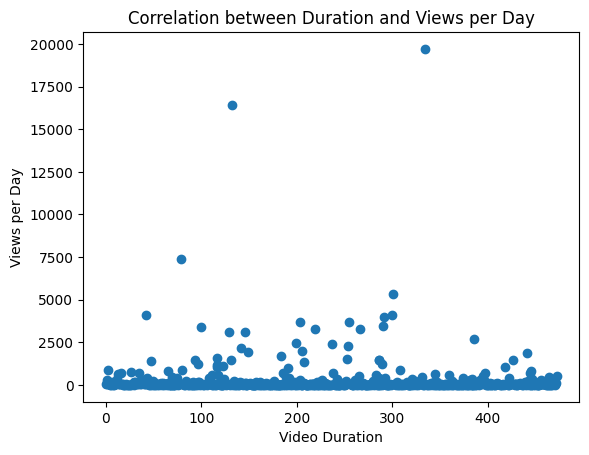

In [14]:
correlation = df['duration_encoded'].corr(df['views_per_day'])
plt.scatter(df['duration_encoded'], df['views_per_day'])
plt.xlabel('Video Duration')
plt.ylabel('Views per Day')
plt.title('Correlation between Duration and Views per Day')
plt.show()

<h4><i>Comment/Like Ratio</h4>

Hiermee kan gekeken worden naar hoe discussie-waardig de inhoud van de video's is. Een hogere discussie waarde kan betekenen dat de inhoud <i>thought-provoking</i> of controversieel is.

In [15]:
df['comment_like_ratio'] = df['comment_count'] / df['likes']

<h4><i>Categorie impact</h4>

Door te kijken naar hoe de prestatie van een video is binnen zijn categorie, kun je zien hoe populair een video is relatief aan hun categorie. Een video met een miljoen views kan bijvoorbeeld in het algemeen wel hoog zijn, maar als video's in deze categorie normaliter minstens vijf miljoen views krijgen, kan dat betekenen dat het een minder populaire video is. 

In [16]:
category_columns = [col for col in df.columns if 'category_id' in col]

category_means = {}
for cat_col in category_columns:
    category_means[cat_col] = df[df[cat_col] == 1]['views'].mean()

df['views_relative_to_category'] = 0.0

for cat_col in category_columns:
    mask = df[cat_col] == 1
    df.loc[mask, 'views_relative_to_category'] = df.loc[mask, 'views'] / category_means[cat_col]

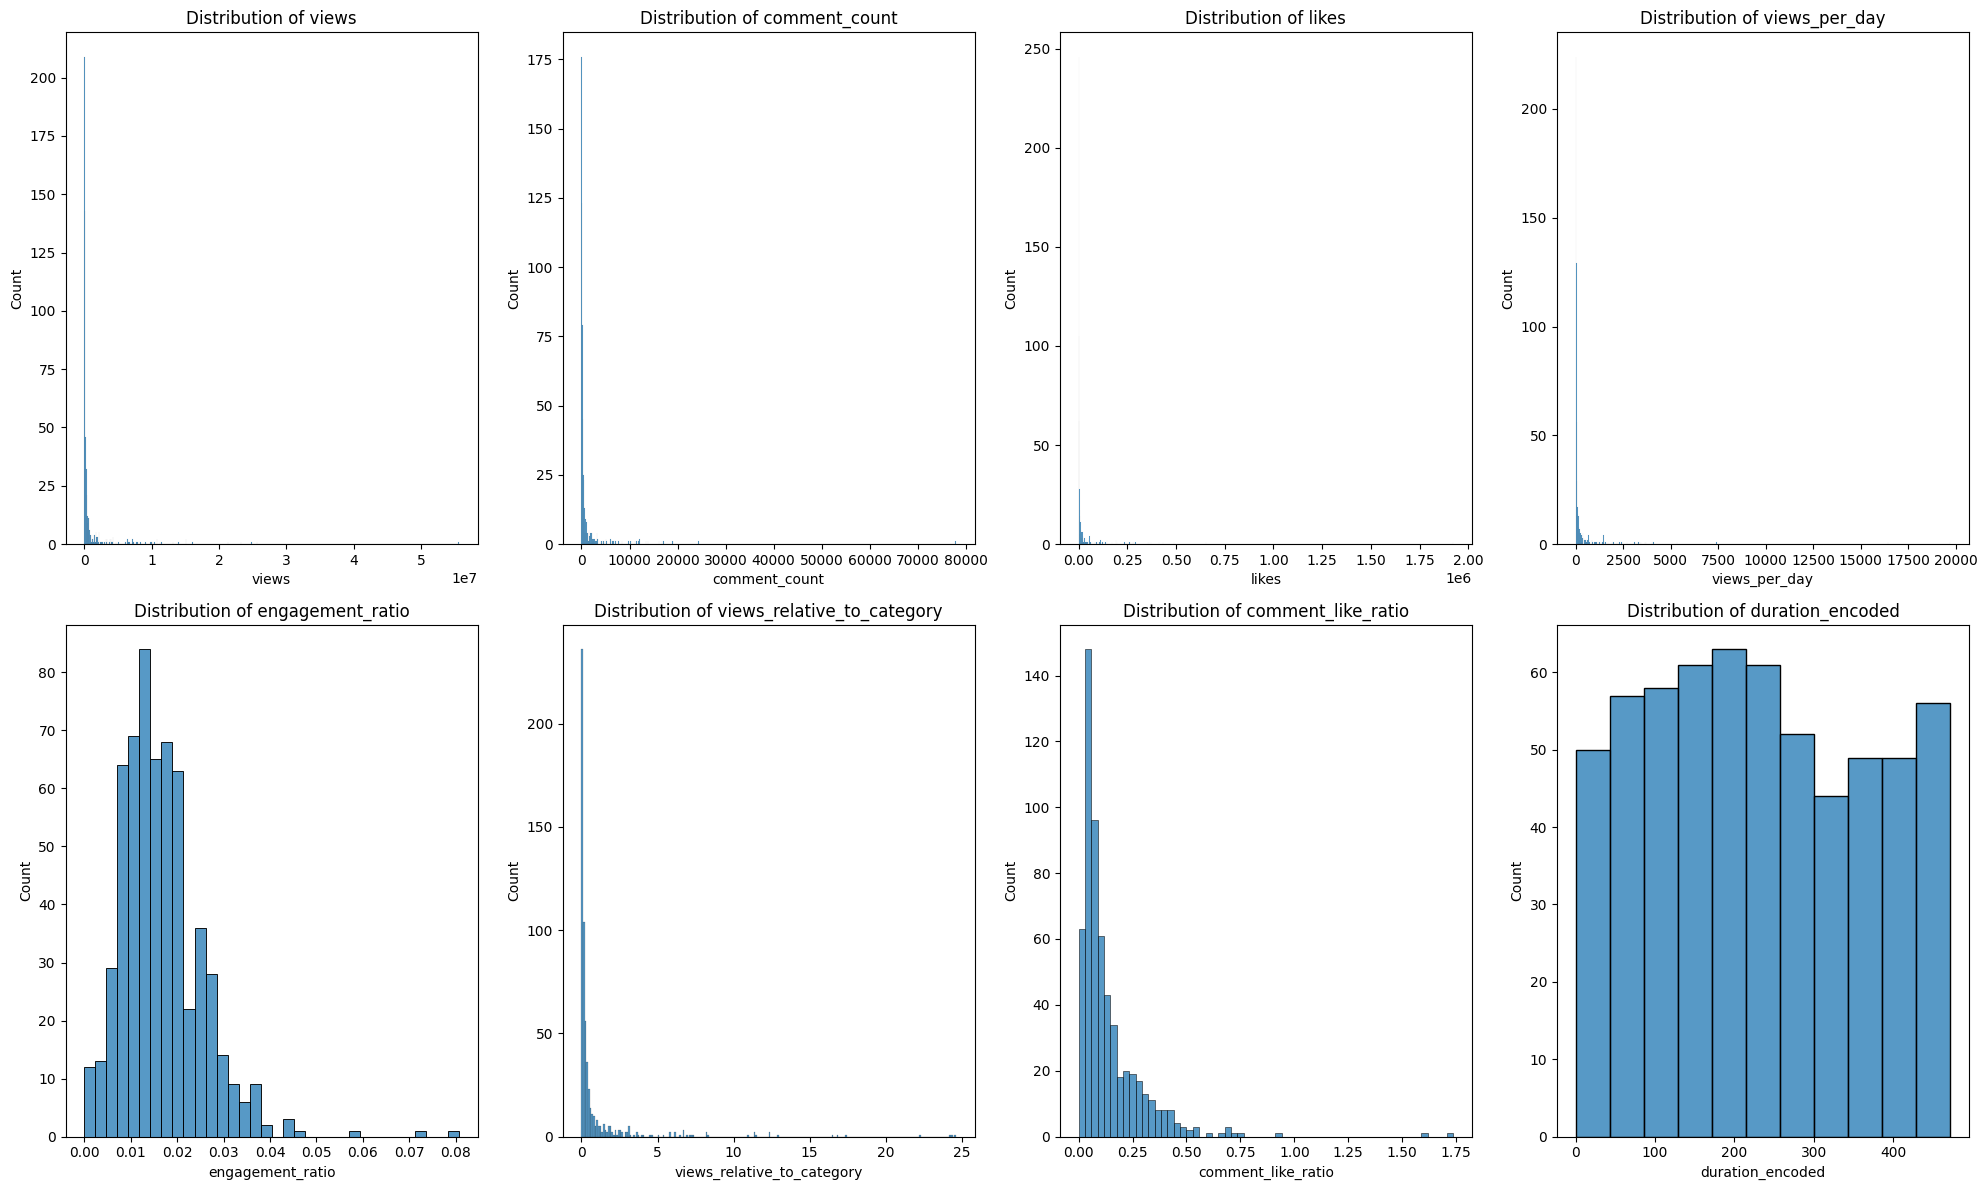

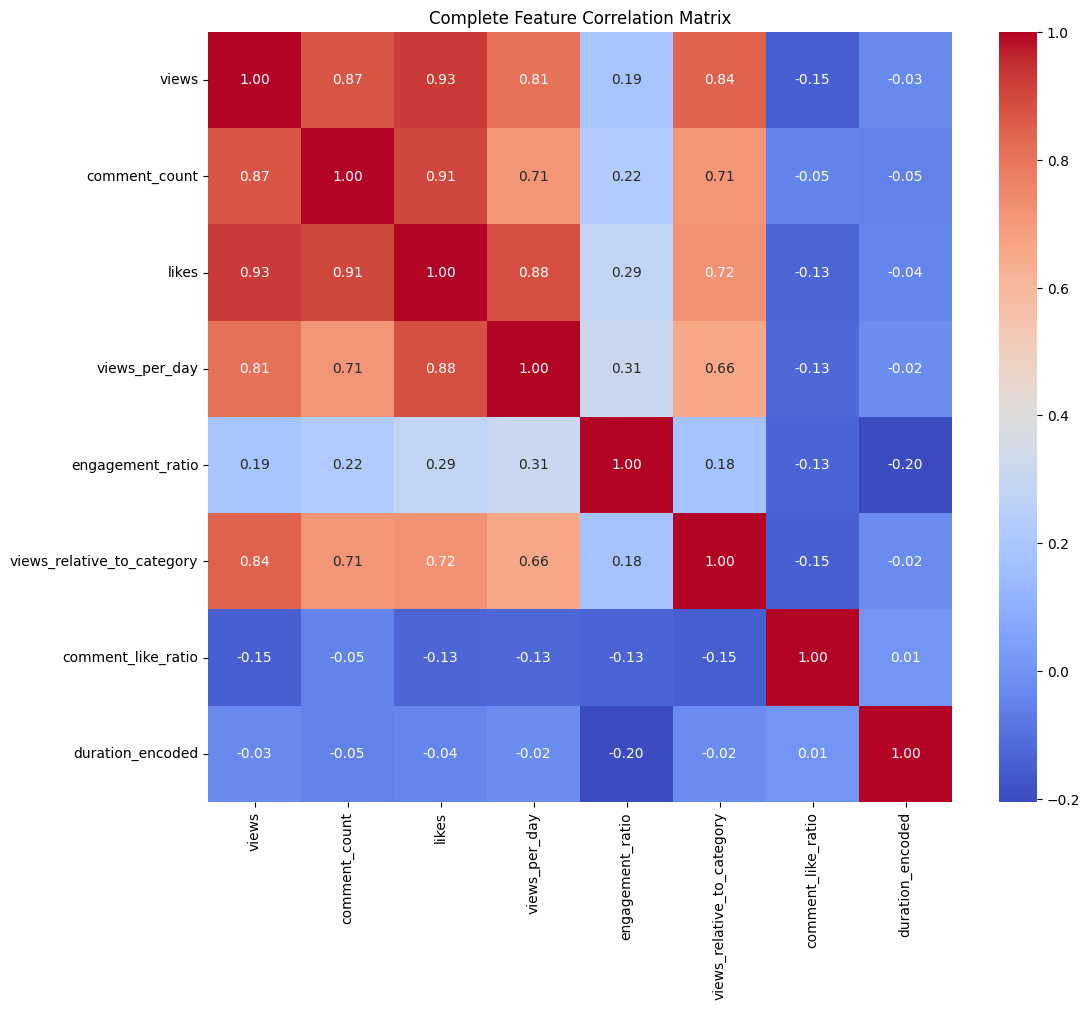


Descriptive Statistics:
              views  comment_count         likes  views_per_day  \
count  6.000000e+02     600.000000  6.000000e+02     600.000000   
mean   1.066151e+06    1070.870000  2.263473e+04     291.317775   
std    3.611008e+06    4055.503954  1.000825e+05    1238.134109   
min    1.000000e+00       0.000000  0.000000e+00       0.000529   
25%    5.922150e+04      86.000000  6.242500e+02      12.225088   
50%    1.332595e+05     202.000000  1.846000e+03      31.528068   
75%    4.101668e+05     511.750000  6.382250e+03     100.715843   
max    5.562224e+07   77980.000000  1.921445e+06   19707.611714   

       engagement_ratio  views_relative_to_category  comment_like_ratio  \
count        600.000000                  600.000000          589.000000   
mean           0.016533                    0.993333            0.137910   
std            0.008873                    2.817498            0.159374   
min            0.000000                    0.000000            0.000000

In [17]:
all_features = [
    'views', 'comment_count', 'likes',  # Basis metrics
    'views_per_day', 'engagement_ratio', 
    'views_relative_to_category', 'comment_like_ratio',
    'duration_encoded'
]

plt.figure(figsize=(20, 12))
for i, feature in enumerate(all_features, 1):
    plt.subplot(2, 4, i)
    sns.histplot(data=df, x=feature)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

correlation_matrix_all = df[all_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Complete Feature Correlation Matrix')
plt.show()

print("\nDescriptive Statistics:")
print(df[all_features].describe())

<i>Duration</i> lijkt een zeer zwakke correlatie te hebben met alle andere features. Daarnaast zal ik ervoor kiezen om de absolute waarden zoals Views, Likes en Comment Count eruit te halen, aangezien die worden meegenomen in een paar van de andere features. 
Ook zit er een duidelijke rechtsscheve verdeling bij alle features behalve duration. Dit suggereert dat er een kleine aantal video's is die een groot aantal views hebben. Er zal onderzoek worden gedaan of dit duidelijke uitschieters zijn en of ze eruit gehaald moeten worden. 

<h3><b>Uitschieters</h2>

Met behulp van de IQR methode zal er worden gekeken naar uitschieters (Outliers). 


Outliers in views_per_day:
Aantal uitschieters: 96
Lower bound: -120.51
Upper bound: 233.45
Min value: 0.00
Max value: 19707.61

Outliers in engagement_ratio:
Aantal uitschieters: 17
Lower bound: -0.00
Upper bound: 0.04
Min value: 0.00
Max value: 0.08

Outliers in views_relative_to_category:
Aantal uitschieters: 92
Lower bound: -0.63
Upper bound: 1.21
Min value: 0.00
Max value: 24.62

Outliers in comment_like_ratio:
Aantal uitschieters: 44
Lower bound: -0.14
Upper bound: 0.36
Min value: 0.00
Max value: 1.74

Totaal aantal unieke rijen met uitschieters: 162
Percentage data uitschieters: 27.00%


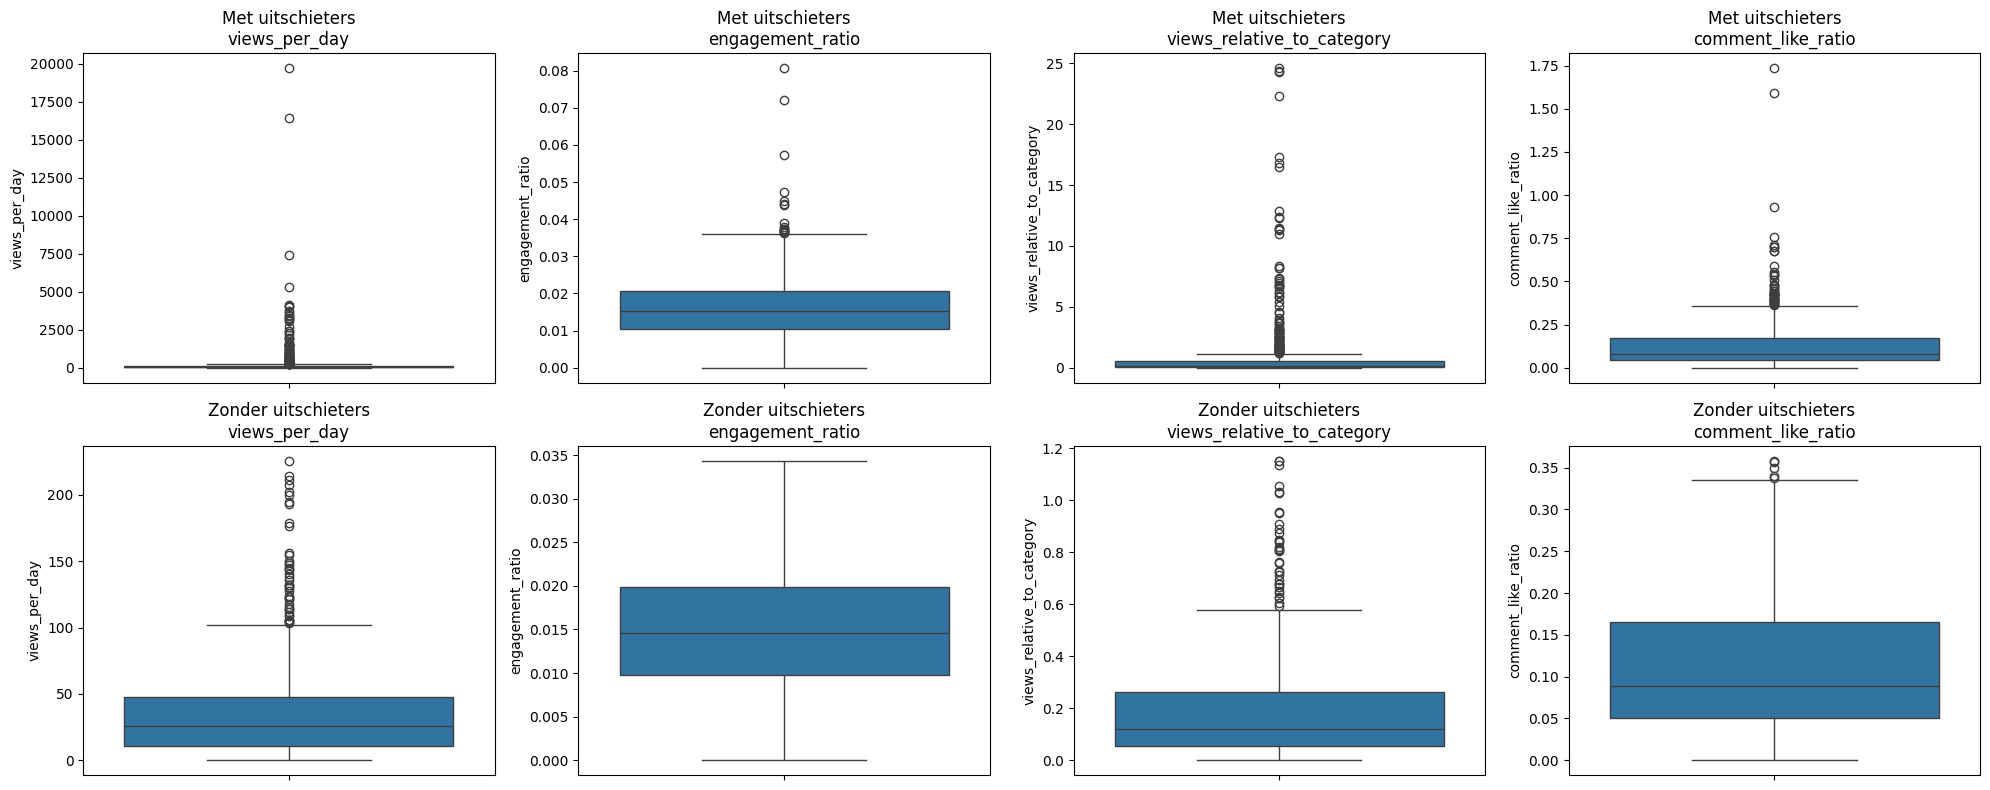

In [18]:
def identify_outliers(df, columns):
    outliers_indices = set()
    
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identificeer uitschieters
        column_outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)].index
        outliers_indices.update(column_outliers)
        
        print(f"\nOutliers in {column}:")
        print(f"Aantal uitschieters: {len(column_outliers)}")
        print(f"Lower bound: {lower_bound:.2f}")
        print(f"Upper bound: {upper_bound:.2f}")
        print(f"Min value: {df[column].min():.2f}")
        print(f"Max value: {df[column].max():.2f}")
    
    return list(outliers_indices)

features = [
    'views_per_day',
    'engagement_ratio',
    'views_relative_to_category',
    'comment_like_ratio'
]

outliers = identify_outliers(df, features)

print(f"\nTotaal aantal unieke rijen met uitschieters: {len(outliers)}")
print(f"Percentage data uitschieters: {(len(outliers)/len(df))*100:.2f}%")

# De data zonder uitschieters
df_no_outliers = df.drop(outliers)

fig, axes = plt.subplots(2, len(features), figsize=(20, 8))

for i, feature in enumerate(features):
    # Original data
    sns.boxplot(data=df, y=feature, ax=axes[0,i])
    axes[0,i].set_title(f'Met uitschieters\n{feature}')
    
    # Data without outliers
    sns.boxplot(data=df_no_outliers, y=feature, ax=axes[1,i])
    axes[1,i].set_title(f'Zonder uitschieters\n{feature}')

plt.tight_layout()
plt.show()


Zoals duidelijk wordt gemaakt in bovenstaande grafieken, is er een behoorlijk aantal uitschieters (27%). Daarnaast is er een aantal uitschieters dat ver boven de bovengrens (derde kwartiel) uitsteekt (e.g. views per day). 
Uit onderzoek blijkt dat Youtube data over het algemeen scheef verdeeld is, omdat sommige video's nu eenmaal <i>viral</i> gaan. Hierom is er gekozen om enkel de extreme uitschieters weg te halen (onder 1% en boven 99%). Er blijft meer data over voor onderzoek hierdoor en de echt onrealistische uitschieters worden dan verwijderd. 

In [19]:
df_clean = df.copy()
for feature in features:
    lower_bound = df[feature].quantile(0.01)  # 1e percentiel
    upper_bound = df[feature].quantile(0.99)  # 99e percentiel
    
    df_clean = df_clean[df_clean[feature].between(lower_bound, upper_bound)]

print(f"Originele dataset grootte: {len(df)}")
print(f"Dataset grootte na verwijderen extreme uitschieters: {len(df_clean)}")
print(f"Percentage behouden data: {(len(df_clean)/len(df)*100):.1f}%")

Originele dataset grootte: 600
Dataset grootte na verwijderen extreme uitschieters: 563
Percentage behouden data: 93.8%


<h4><b>Data schalen

In [20]:
def prepare_features(df):
    features = ['views_per_day', 
               'engagement_ratio', 
               'views_relative_to_category',
               'duration_encoded',
               'comment_like_ratio']

    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df[features])
    
    return scaled_features

<h2><b>Cluster Analyse</h2>

In [21]:
scaled_features = prepare_features(df_clean)

def apply_kmeans(scaled_features, n_clusters=2):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(scaled_features)
    return clusters, kmeans


Cluster Statistieken:
        views_per_day                  engagement_ratio               \
                 mean   median     std             mean median   std   
cluster                                                                
0               79.66    28.71  144.36             0.02   0.01  0.01   
1             1799.10  1481.18  868.93             0.02   0.02  0.01   

        views_relative_to_category              comment_like_ratio         \
                              mean median   std               mean median   
cluster                                                                     
0                             0.39   0.16  0.64               0.14   0.09   
1                             6.57   6.01  3.67               0.05   0.04   

              duration_encoded                 
          std             mean median     std  
cluster                                        
0        0.12           233.38  224.0  136.55  
1        0.05           196.69  195.5 

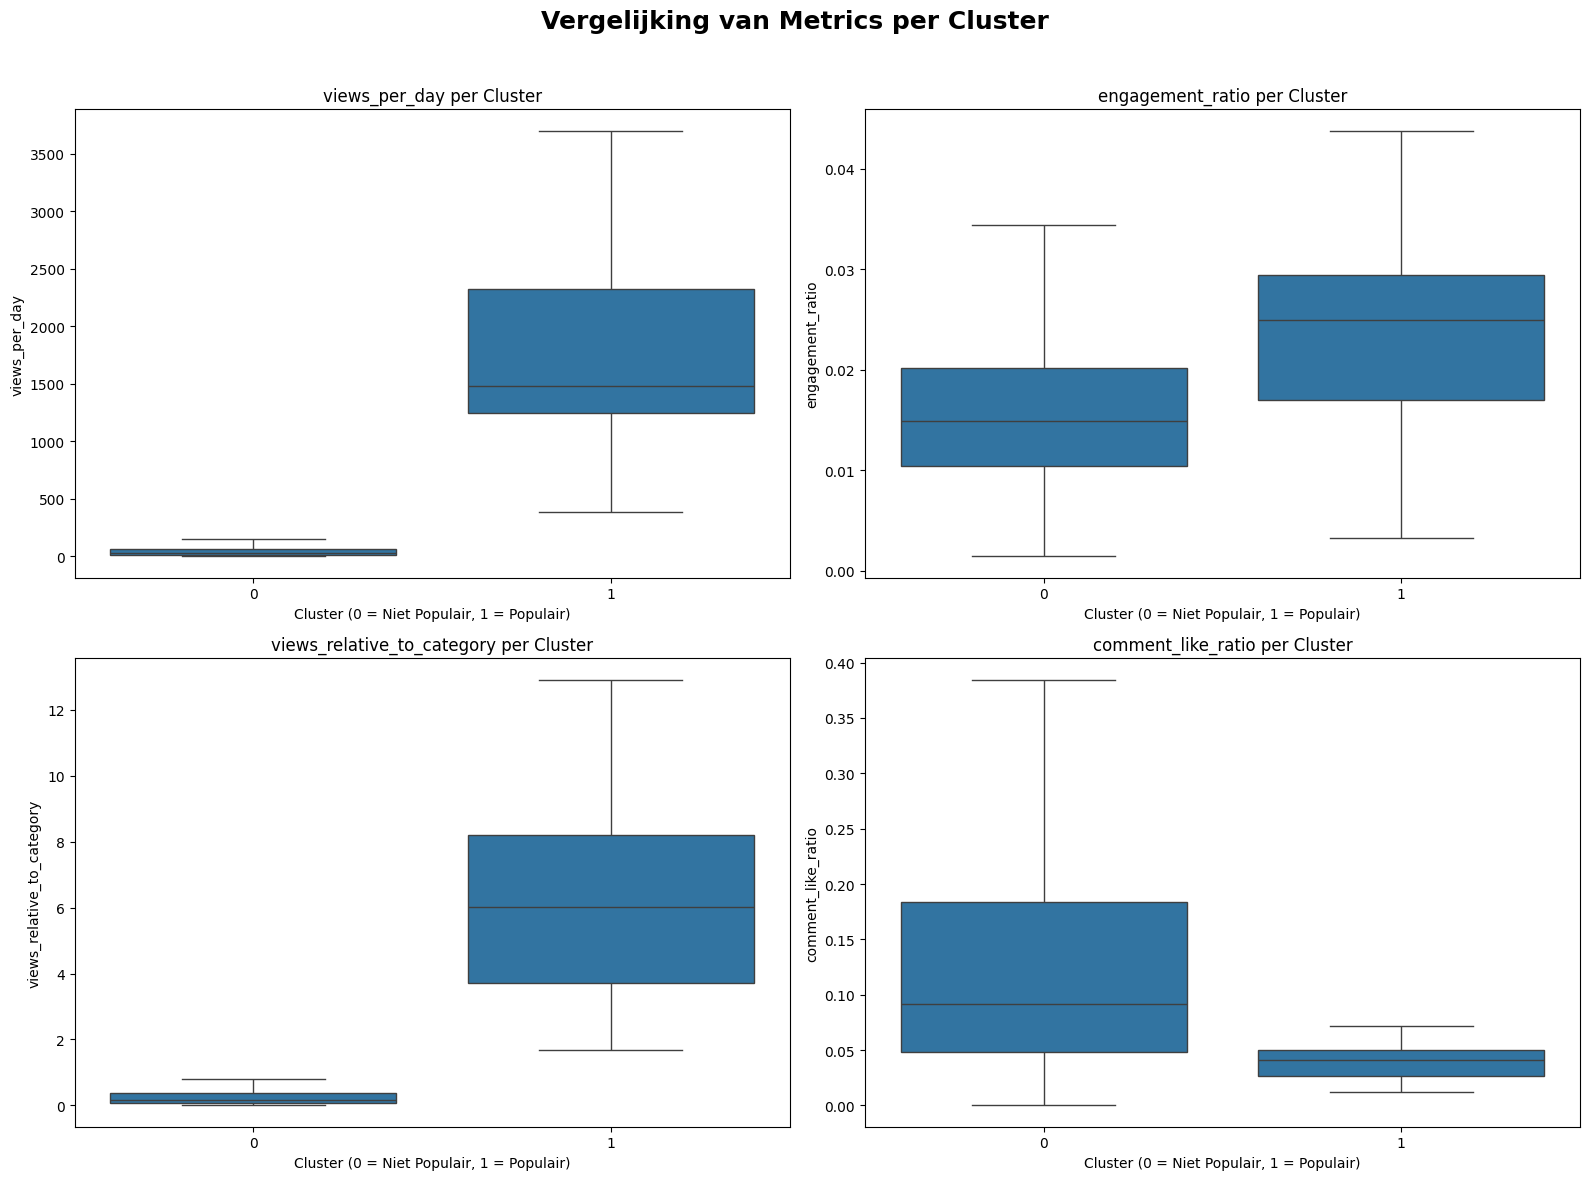


Karakteristieke videos voor cluster 0:
                                                              title  views_per_day  engagement_ratio  views_relative_to_category
                 The bridge between suicide and life | Kevin Briggs    1054.470228          0.031000                    1.904754
                        The mad scientist of music | Mark Applebaum     998.758985          0.012937                    3.060450
I am the son of a terrorist. Here's how I chose peace | Zak Ebrahim     845.622004          0.030228                    1.483331
                      The happy secret to better work | Shawn Achor     840.973952          0.013573                    1.829176
                What you don't know about marriage | Jenna McCarthy     750.293410          0.011246                    1.627623

Karakteristieke videos voor cluster 1:
                                                           title  views_per_day  engagement_ratio  views_relative_to_category
Your brain hallucina

In [22]:
clusters, kmeans_model = apply_kmeans(scaled_features, n_clusters=2)

def analyze_clusters(df, clusters):
    df = df.copy()
    df['cluster'] = clusters.astype(str)
    
    cluster_stats = df.groupby('cluster').agg({
        'views_per_day': ['mean', 'median', 'std'],
        'engagement_ratio': ['mean', 'median', 'std'],
        'views_relative_to_category': ['mean', 'median', 'std'],
        'comment_like_ratio': ['mean', 'median', 'std'],
        'duration_encoded': ['mean', 'median', 'std']
    }).round(2)
    
    print("\nCluster Statistieken:")
    print("====================")
    print(cluster_stats)
    
    metrics = ['views_per_day', 'engagement_ratio', 
              'views_relative_to_category', 'comment_like_ratio']
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()
    
    for idx, metric in enumerate(metrics):
        sns.boxplot(x='cluster', y=metric, data=df, ax=axes[idx], showfliers=False)
        axes[idx].set_title(f'{metric} per Cluster')
        axes[idx].set_xlabel('Cluster (0 = Niet Populair, 1 = Populair)')

    plt.suptitle('Vergelijking van Metrics per Cluster', fontsize=18, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    for cluster in sorted(df['cluster'].unique()):
        print(f"\nKarakteristieke videos voor cluster {cluster}:")
        cluster_df = df[df['cluster'] == cluster]
        top_videos = cluster_df.nlargest(5, 'views_per_day')[
            ['title', 'views_per_day', 'engagement_ratio', 'views_relative_to_category']
        ]
        print(top_videos.to_string(index=False))
        
analyze_clusters(df_clean, clusters)

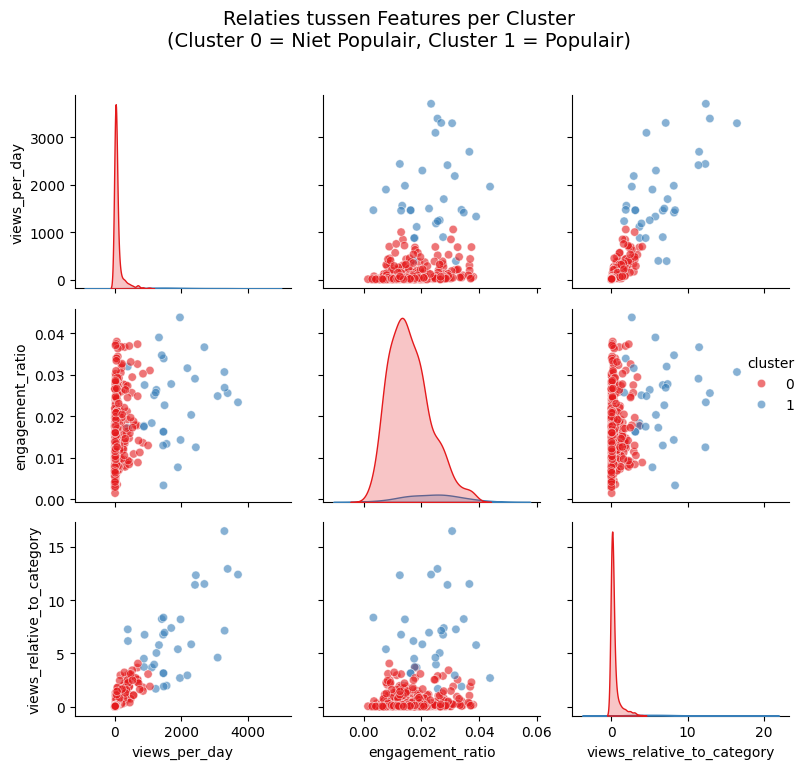

In [23]:
def plot_clusters(df, clusters, features_to_plot=None):
    df_plot = df.copy()
    df_plot['cluster'] = clusters
    
    if features_to_plot is None:
        features_to_plot = [
            'views_per_day',
            'engagement_ratio',
            'views_relative_to_category',
            'comment_like_ratio',
            'duration_encoded'
        ]
    
    g = sns.pairplot(df_plot, 
                     vars=features_to_plot, 
                     hue='cluster',
                     palette='Set1',
                     diag_kind='kde',
                     plot_kws={'alpha': 0.6}) 
    
    g.fig.suptitle('Relaties tussen Features per Cluster\n(Cluster 0 = Niet Populair, Cluster 1 = Populair)', 
                   y=1.02, 
                   fontsize=14)
    
    plt.tight_layout()
    plt.show()

scaled_features = prepare_features(df_clean)
clusters, kmeans_model = apply_kmeans(scaled_features)

selected_features = [
    'views_per_day',
    'engagement_ratio',
    'views_relative_to_category'
]
plot_clusters(df_clean, clusters, selected_features)

In [24]:
def interpret_clusters(df, clusters):
    df['Cluster'] = clusters
    
    cluster_means = df.groupby('Cluster').agg({
        'views_per_day': 'mean',
        'engagement_ratio': 'mean',
        'views_relative_to_category': 'mean',
        'comment_like_ratio': 'mean'
    }).round(3)
    
    print("\nGemiddelde waarden per cluster:")
    print("===============================")
    print(cluster_means)
    
    cluster_sizes = df['Cluster'].value_counts().sort_index()
    print("\nAantal videos per cluster:")
    print(cluster_sizes)
    
    return cluster_means

interpret_clusters(df_clean, clusters)


Gemiddelde waarden per cluster:
         views_per_day  engagement_ratio  views_relative_to_category  \
Cluster                                                                
0               79.664             0.016                       0.394   
1             1799.098             0.024                       6.567   

         comment_like_ratio  
Cluster                      
0                     0.136  
1                     0.049  

Aantal videos per cluster:
Cluster
0    531
1     32
Name: count, dtype: int64


,views_per_day,engagement_ratio,views_relative_to_category,comment_like_ratio
Cluster,,,,
0,79.664,0.016,0.394,0.136
1,1799.098,0.024,6.567,0.049


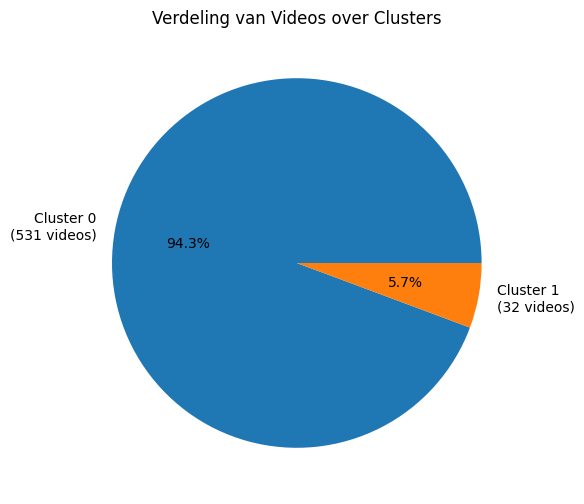

In [25]:
def plot_cluster_distribution(df, clusters):
    plt.figure(figsize=(10, 6))
    
    cluster_sizes = pd.Series(clusters).value_counts()
    plt.pie(cluster_sizes, labels=[f'Cluster {i}\n({v} videos)' 
            for i, v in cluster_sizes.items()],
            autopct='%1.1f%%')
    
    plt.title('Verdeling van Videos over Clusters')
    plt.show()

plot_cluster_distribution(df_clean, clusters)

In [26]:
from IPython.display import display, Markdown

def generate_conclusions(df, clusters, cluster_means):
    cluster_sizes = pd.Series(clusters).value_counts(normalize=True) * 100
    views_ratio = (cluster_means.loc[1, 'views_per_day'] / 
                  cluster_means.loc[0, 'views_per_day'])
    
    conclusions = f"""
## **Cluster Analyse Resultaten**

### Cluster Verdeling:
- Cluster 0 (Niet Populair): {cluster_sizes[0]:.1f}% van de videos ({int(cluster_sizes[0]*len(df)/100)} videos)
- Cluster 1 (Populair): {cluster_sizes[1]:.1f}% van de videos ({int(cluster_sizes[1]*len(df)/100)} videos)

### Cluster Karakteristieken:
- **Cluster 0 (Niet Populair):**
  - Gemiddeld {cluster_means.loc[0, 'views_per_day']:.1f} views per dag
  - Engagement ratio: {cluster_means.loc[0, 'engagement_ratio']:.3f}
  - Relatieve views t.o.v. categorie: {cluster_means.loc[0, 'views_relative_to_category']:.2f}
  - Comment/like ratio: {cluster_means.loc[0, 'comment_like_ratio']:.3f}

- **Cluster 1 (Populair):**
  - Gemiddeld {cluster_means.loc[1, 'views_per_day']:.1f} views per dag
  - Engagement ratio: {cluster_means.loc[1, 'engagement_ratio']:.3f}
  - Relatieve views t.o.v. categorie: {cluster_means.loc[1, 'views_relative_to_category']:.2f}
  - Comment/like ratio: {cluster_means.loc[1, 'comment_like_ratio']:.3f}

### Belangrijkste Bevindingen:
1. Er is een duidelijke scheiding tussen populaire ({cluster_sizes[1]:.1f}%) en niet populaire ({cluster_sizes[0]:.1f}%) videos
2. Populaire videos krijgen gemiddeld {views_ratio:.1f}x meer views per dag
3. Populaire videos scoren {cluster_means.loc[1, 'views_relative_to_category']/cluster_means.loc[0, 'views_relative_to_category']:.1f}x hoger binnen hun categorie
4. Opvallend is dat populaire videos een lagere comment/like ratio hebben
"""
    
    display(Markdown(conclusions))
    return conclusions

cluster_means = interpret_clusters(df_clean, clusters)
conclusions = generate_conclusions(df_clean, clusters, cluster_means)


Gemiddelde waarden per cluster:
         views_per_day  engagement_ratio  views_relative_to_category  \
Cluster                                                                
0               79.664             0.016                       0.394   
1             1799.098             0.024                       6.567   

         comment_like_ratio  
Cluster                      
0                     0.136  
1                     0.049  

Aantal videos per cluster:
Cluster
0    531
1     32
Name: count, dtype: int64



## **Cluster Analyse Resultaten**

### Cluster Verdeling:
- Cluster 0 (Niet Populair): 94.3% van de videos (531 videos)
- Cluster 1 (Populair): 5.7% van de videos (32 videos)

### Cluster Karakteristieken:
- **Cluster 0 (Niet Populair):**
  - Gemiddeld 79.7 views per dag
  - Engagement ratio: 0.016
  - Relatieve views t.o.v. categorie: 0.39
  - Comment/like ratio: 0.136

- **Cluster 1 (Populair):**
  - Gemiddeld 1799.1 views per dag
  - Engagement ratio: 0.024
  - Relatieve views t.o.v. categorie: 6.57
  - Comment/like ratio: 0.049

### Belangrijkste Bevindingen:
1. Er is een duidelijke scheiding tussen populaire (5.7%) en niet populaire (94.3%) videos
2. Populaire videos krijgen gemiddeld 22.6x meer views per dag
3. Populaire videos scoren 16.7x hoger binnen hun categorie
4. Opvallend is dat populaire videos een lagere comment/like ratio hebben


<h2><b>Getrainde modellen opslaan</h2>

In [27]:
model_filename = 'clustering_model.joblib'
joblib.dump(kmeans_model, model_filename)

scaler = StandardScaler()
scaler.fit(df_clean[['views_per_day', 
                     'engagement_ratio', 
                     'views_relative_to_category',
                     'duration_encoded',
                     'comment_like_ratio']])
scaler_filename = 'scaler.joblib'
joblib.dump(scaler, scaler_filename)

print(f"Model opgeslagen als: {model_filename}")
print(f"Scaler opgeslagen als: {scaler_filename}")


Model opgeslagen als: clustering_model.joblib
Scaler opgeslagen als: scaler.joblib
